# Blocked vs. Interspersed presentation of tasks
Comparing the normal presentation of tasks (seperated in blocks) 
with the MDTB-style interspersed presentation of tasks.

In [1]:
import numpy as np
from numpy.linalg import inv,eig,eigh
import PcmPy as pcm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from numpy import sqrt


In [2]:
# These are the main functions
def make_design_matrix(reg_id = [[1,2],[3,4],[5,6]],
                       p_rest=0.2,
                       T=100):
    """ Make a design matrix with the conditions
    indicated in reg_id and rest phase with probability p_rest"""
     # Number of possible runs
    num_part  = len(reg_id) # Number of tasks including rest (0)
    part_v = np.kron(np.arange(num_part),np.ones((T)))
    reg_ind = np.concatenate(reg_id)
    # Get the partition index for the columns of the design matrix
    part_ind = [np.ones(len(r))*i for i,r in enumerate(reg_id)]
    part_ind = np.concatenate(part_ind)
    # Start building the design matrix
    X = np.zeros((T*num_part,reg_ind.shape[0]))
    cv = []
    # For each partition (run) find the number of available scans an allocate
    for i in range(num_part):
        num_cond = len(reg_id[i])
        # Number of TR per condiiton depend on even number of TRs
        lc = int((T-T*p_rest)//num_cond)
        lr = T - lc * num_cond
        # build the condition vector
        ccvv = np.array(reg_id[i])
        cond_v = np.kron(ccvv,np.ones((lc,)))
        cond_v = np.concatenate((cond_v,np.zeros((lr,))))
        cv.append(cond_v)
        row=np.where(part_v==i)[0]
        col=np.where(part_ind==i)[0]
        X[np.ix_(row,col)]=pcm.matrix.indicator(cond_v,positive=True)
    cond_v = np.concatenate(cv)
    X=np.concatenate([X,pcm.indicator(part_v)],axis=1)
    reg_ind = np.concatenate([reg_ind,np.zeros(num_part)])
    # Use the first condition to get a measure of TR per condition
    lc = (cond_v==1).sum()
    lr = (cond_v==0).sum()
    return X,cond_v,part_v,reg_ind,part_ind,lc,lr

def var_contrasts(X,reg_ind):
    """ Calculate the variance you would get for contrasts on beta-estimates
    from a design matrix X the regressors indicating different conditions
    We do this seperately for all contrast against rest
    and all the pairwise contrasts between conditions.
    """
    conv_beta = inv(X.T@X)
    # CI are the contrast against rest
    CI = pcm.matrix.indicator(reg_ind,positive=True).T
    CI = CI / CI.sum(axis=1,keepdims=True)
    # CP are the pairwise contrast
    CP = pcm.matrix.pairwise_contrast(reg_ind,positive=True)
    var_i = np.diag(CI@conv_beta@CI.T)
    var_p = np.diag(CP@conv_beta@CP.T)
    return var_i,var_p

def compare_designs(design=None,
                    T=90,
                    p_rest=[0.7,0.6,1/2,1/2.5,1/3,1/4,1/5,1/6,1/7,1/8,1/9,1/11,1/15]):
    """ Compares the blocked (like HCP) and interspersed (like MDTB)
    designs across a set of resting probabilities"""
    if design is None:
        design = []
        design.append([[1,2],[3,4],[5,6]]) # Blocked design
        design.append([[1,2,3,4,5,6]]*3) # Intersperse design

    # get unique indices from one of the designs
    n_unique = len(np.unique(np.concatenate(design[0])))
    n_contrasts = n_unique*(n_unique-1)//2

    ci = np.zeros(n_contrasts,dtype=bool)
    ci[[0,5]]=True # THese are the within-run contrast
    DF = pd.DataFrame()
    for rp in p_rest:
        for i,d in enumerate(design):
            X,_,_,reg,_,lc,lr = make_design_matrix(d,rp,T)
            vari,varp = var_contrasts(X,reg)
            df = {'Design':[i],
                  'length_rest':[lr],
                  'p_rest':[lr/(T*len(d))],
                  'length_cond':[lc],
                  'std_vs_rest':sqrt(vari.mean()),
                  'std_pairwise':sqrt(varp.mean()),
                  'std_pairwisew':sqrt(varp[ci].mean()),
                  'std_pairwiseb':sqrt(varp[~ci].mean())}
            DF = pd.concat([DF,pd.DataFrame(df)],ignore_index=True)
    return DF


[1. 2. 3. 4. 0. 0.]


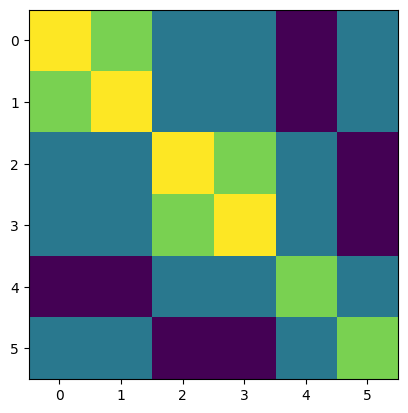

In [3]:
# For checking - this is covariance matrix between
# Estimates from a blocked design
design_b=[[1,2],[3,4]] # Blocked design
X1,_,_,reg1,_,_,_ = make_design_matrix(design_b)
print(reg1)
conv_beta = inv(X1.T@X1)
plt.imshow(conv_beta)

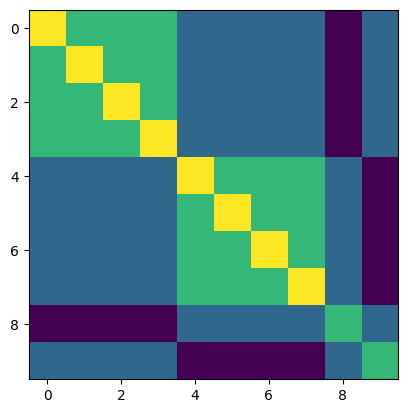

In [4]:
# THis is the covariance matrix for the regressors
# For an interspersed design
design_i=[[1,2,3,4]]*2 # Intersperse design
X2,_,_,reg2,_,_,_ = make_design_matrix(design_i)
conv_beta = inv(X2.T@X2)
plt.imshow(conv_beta)

In [5]:
# Now we are calculating the std of the
# contrast against rest
# contrast of different conditions (within runs)
# contrast of different conditions (between runs)

T=300
numpart = len(design_b)
DF = compare_designs([design_b,design_i],T)
DF


,Design,length_rest,p_rest,length_cond,std_vs_rest,std_pairwise,std_pairwisew,std_pairwiseb
0,0,420,0.700000,45,0.164268,0.225374,0.210819,0.232311
1,1,424,0.706667,44,0.158385,0.213201,0.213201,0.213201
2,0,360,0.600000,60,0.149071,0.201843,0.182574,0.210819
3,1,360,0.600000,60,0.139443,0.182574,0.182574,0.182574
4,0,300,0.500000,75,0.141421,0.188562,0.163299,0.200000
5,1,304,0.506667,74,0.129626,0.164399,0.164399,0.164399
6,0,240,0.400000,90,0.139443,0.182574,0.149071,0.197203
7,1,240,0.400000,90,0.123603,0.149071,0.149071,0.149071
8,0,200,0.333333,100,0.141421,0.182574,0.141421,0.200000
9,1,200,0.333333,100,0.122474,0.141421,0.141421,0.141421


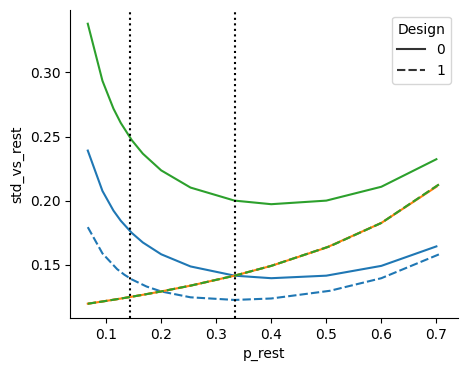

In [6]:
# Make the plot.
plt.figure(figsize=(5,4))
sb.lineplot(data=DF,x='p_rest',y='std_vs_rest',style='Design')
sb.lineplot(data=DF,x='p_rest',y='std_pairwisew',style='Design',legend=False)
sb.lineplot(data=DF,x='p_rest',y='std_pairwiseb',style='Design',legend=False)
plt.axvline(1/7,color='black',linestyle=':')
plt.axvline(1/3,color='black',linestyle=':')
# Remove the box around the plot
sb.despine()



Between-condition contrasts: 
For the interspersed design (dashed lines), all between-conditions contrast can be made within run (yellow line) - that is, conditions can be directly compared to each other without reference to rest. Therefore the SD of these contrast gets smaller as the probability of rest get smaller (and therefore the TRs dedicated each of the conditions longer). 

For the blocked designed (solid lines) the few contrast that can be made within run behave exactly like for the interspersed condition. Most contrasts, however need to be made between runs and have therefore much higher standard deviation (green solid curve). All of these contrast implicitly rely on the contrast to rest and therefore are minimized when rest within each run is just as long as each condition (p=0.33)

Contrasts vs,. rest: 
Finally, the SD of the contrast of each condition against rest (solid blue line) is lower than for the between-run contrasts, as it relies only on a direct contrast. It is equal to the SD of a within-run contrast if rest has as many TRs as the conditions (p=0.33). However for the interspersed design, the SD is substantially lower. Indeed, here we can make rest just as long as the other conditions (p=1/7) to be as good as the within-run contrasts. 

Overall, these simulations show that an interspersed design is quite advantagous even for condition vs. rest contrast, as we do not need as much rest to optimize the design. Most importantly it has a big benefit of allowing strong between conditions for all conditions pairs.


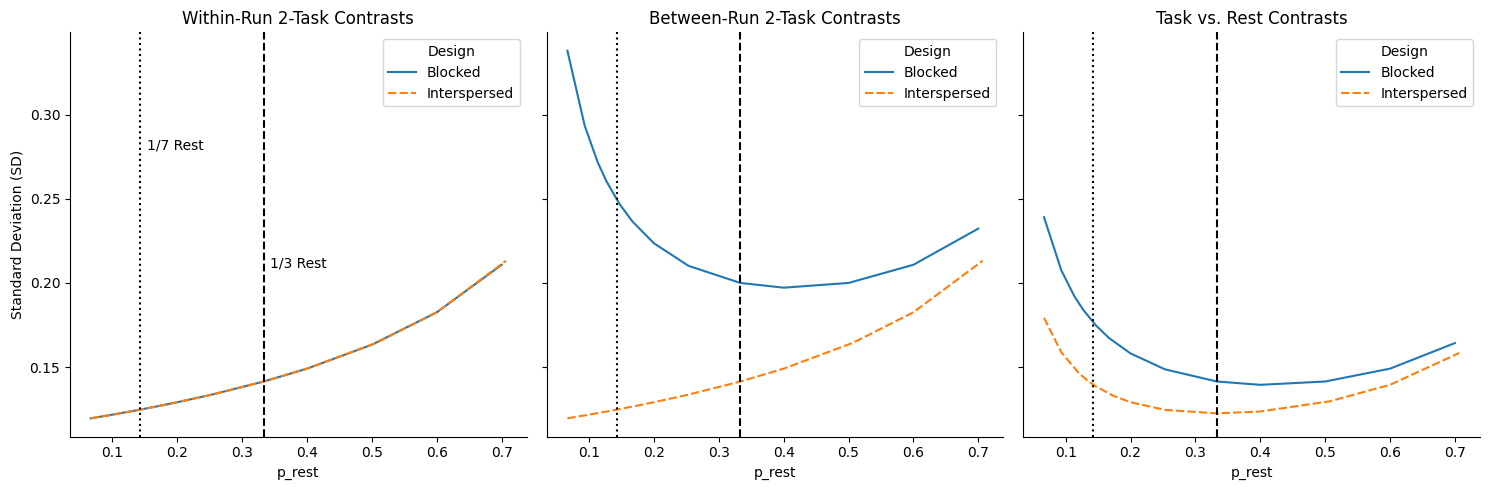

In [7]:
DF['Design'] = DF['Design'].replace({0: 'Blocked', 1: 'Interspersed'})

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# Plot within-run contrasts
sb.lineplot(data=DF, x='p_rest', y='std_pairwisew', hue='Design', style='Design',
            markers=False, ax=axs[0])
axs[0].set_title('Within-Run 2-Task Contrasts')
axs[0].set_ylabel('Standard Deviation (SD)')

# Plot between-run contrasts
sb.lineplot(data=DF, x='p_rest', y='std_pairwiseb', hue='Design', style='Design',
            markers=False, ax=axs[1])
axs[1].set_title('Between-Run 2-Task Contrasts')
axs[1].set_ylabel('')

# Plot contrast vs. rest
sb.lineplot(data=DF, x='p_rest', y='std_vs_rest', hue='Design', style='Design',
            markers=False, ax=axs[2])
axs[2].set_title('Task vs. Rest Contrasts')
axs[2].set_ylabel('')

for ax in axs:
    ax.axvline(1/7, color='black', linestyle=':', label='1/7 Rest')
    ax.axvline(1/3, color='black', linestyle='--', label='1/3 Rest')

# Annotate the lines
axs[0].text(1/7 + 0.01, axs[0].get_ylim()[1] * 0.8, '1/7 Rest', color='black', fontsize=10)
axs[0].text(1/3 + 0.01, axs[0].get_ylim()[1] * 0.6, '1/3 Rest', color='black', fontsize=10)

plt.tight_layout()

# Remove top and right spines
sb.despine(fig=fig)

# Show the plot
plt.show()
